In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# Load the data
df = pd.read_csv('./datasets/MBTA-Bus-Arrival-Departure-Times_2024-12.csv')


In [13]:
# Parse actual times into datetime (ignore rows where actual is missing)
df['actual'] = pd.to_datetime(df['actual'], utc=True, errors='coerce')
df = df.dropna(subset=['actual'])


In [14]:
#Filter start and end points
start_df = df[df['point_type'] == 'Startpoint'][['half_trip_id', 'route_id', 'direction_id', 'actual']]
end_df = df[df['point_type'] == 'Endpoint'][['half_trip_id', 'actual']]

# Rename columns
start_df = start_df.rename(columns={'actual': 'start_time'})
end_df = end_df.rename(columns={'actual': 'end_time'})

In [15]:
# Merge to get start and end time per trip
trip_times = pd.merge(start_df, end_df, on='half_trip_id', how='inner')

# Compute trip duration in minutes
trip_times['duration_min'] = (trip_times['end_time'] - trip_times['start_time']).dt.total_seconds() / 60

# Aggregate: average duration per route and direction
agg = trip_times.groupby(['route_id', 'direction_id'])['duration_min'].mean().reset_index()

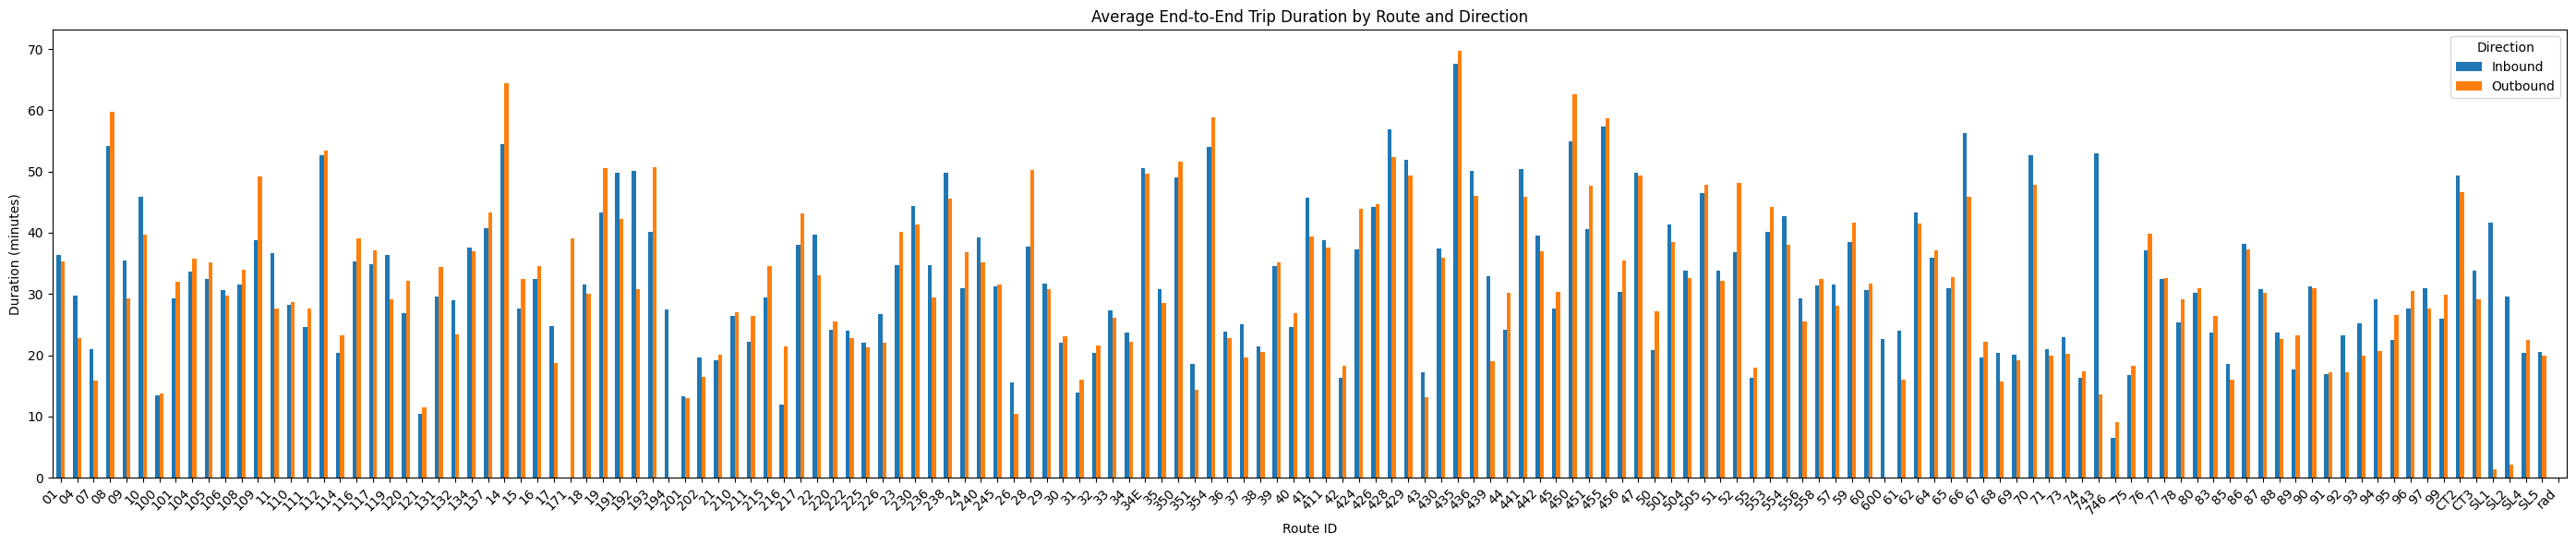

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(28, 6))
pivot.plot(kind='bar', ax=ax)
ax.set_title('Average End-to-End Trip Duration by Route and Direction')
ax.set_ylabel('Duration (minutes)')
ax.set_xlabel('Route ID')
ax.legend(title='Direction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()